<a href="https://colab.research.google.com/github/aqilfiras/California-Housing-Prices-Prediction/blob/main/house_pricing_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [136]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
import numpy as np
from sklearn.impute import KNNImputer
import seaborn as sns
import geoplot as gplt
import geoplot.crs as gcrs

In [126]:
df = pd.read_csv('data/housing.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [127]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [128]:
train, test = train_test_split(df, test_size = 0.2, random_state=42)

In [129]:
def knn_impute(df: pd.DataFrame) -> pd.DataFrame:
    nums = df.select_dtypes(include=np.number)
    num_cols = nums.columns.tolist()
    cat = df.select_dtypes(exclude=np.number)
    imputer = KNNImputer(n_neighbors=5)
    nums_imputed  = pd.DataFrame(imputer.fit_transform(nums), columns=num_cols)
    df_imputed = pd.concat([nums_imputed,cat])
    return df_imputed

train_imputed = knn_impute(train)
test_imputed = knn_impute(test)
train.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 14196 to 15795
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.4 MB


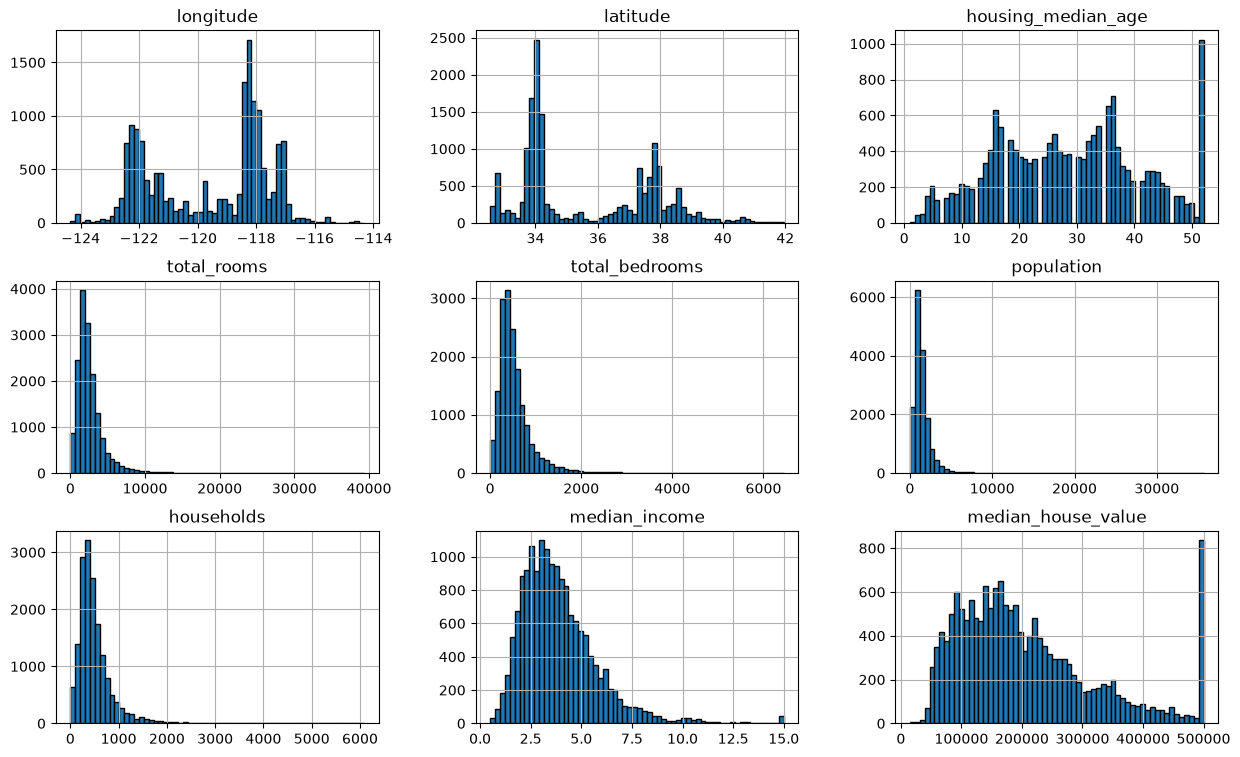

In [130]:
train_imputed.hist(bins = 60, edgecolor = 'black', figsize=(15,9))
plt.show()

In [131]:
train_imputed['median_house_value'].describe()

count     16512.000000
mean     207194.693738
std      115622.626448
min       14999.000000
25%      119800.000000
50%      179850.000000
75%      265125.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [132]:
def feature_eng(df: pd.DataFrame) -> pd.DataFrame:
    res = df.copy()
    res['bedroom_per_rooms'] = res['total_bedrooms']/res['total_rooms']
    res['diag_coord'] = res['longitude'] + res['latitude']
    res['pop_per_house'] = res['population']/res['households']
    return res

train_imputed = feature_eng(train_imputed)
test_imputed = feature_eng(test_imputed)

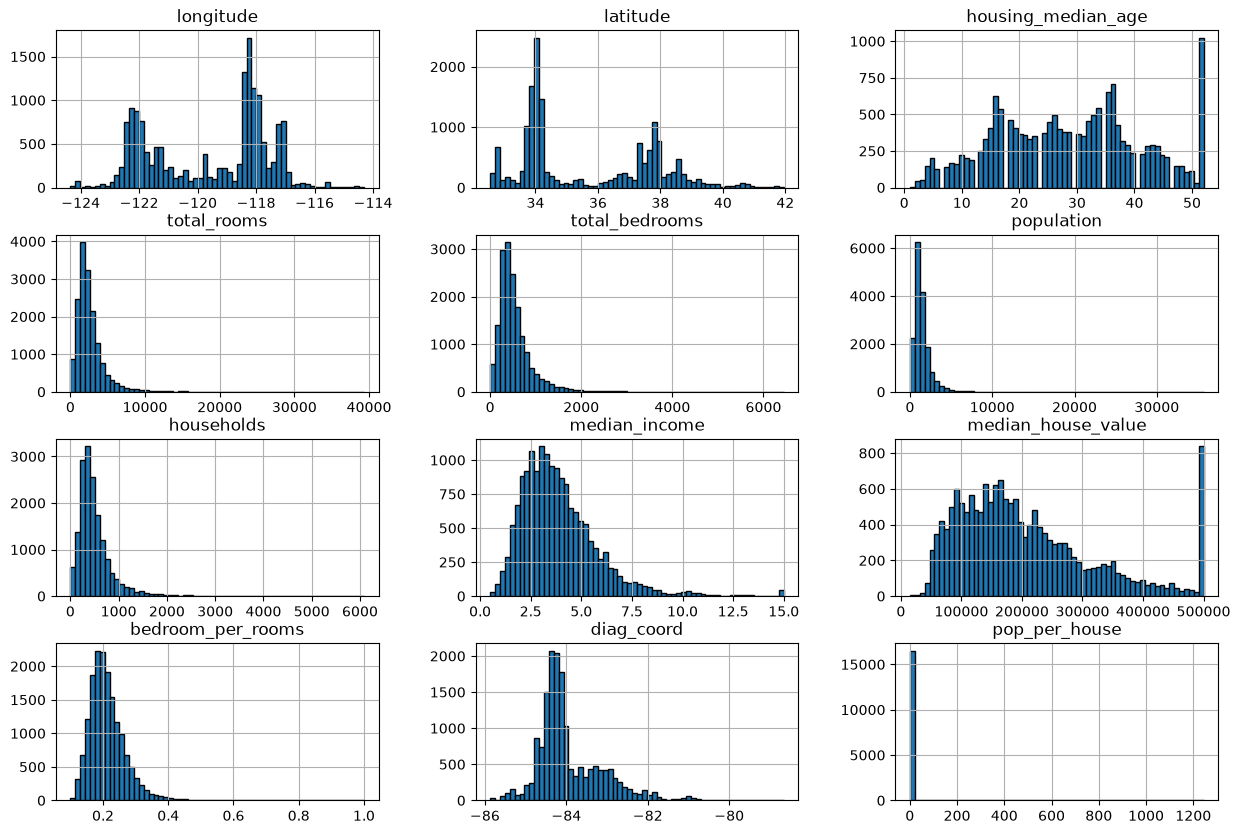

In [133]:
train_imputed.hist(bins = 60, edgecolor = 'black', figsize=(15,10))
plt.show()

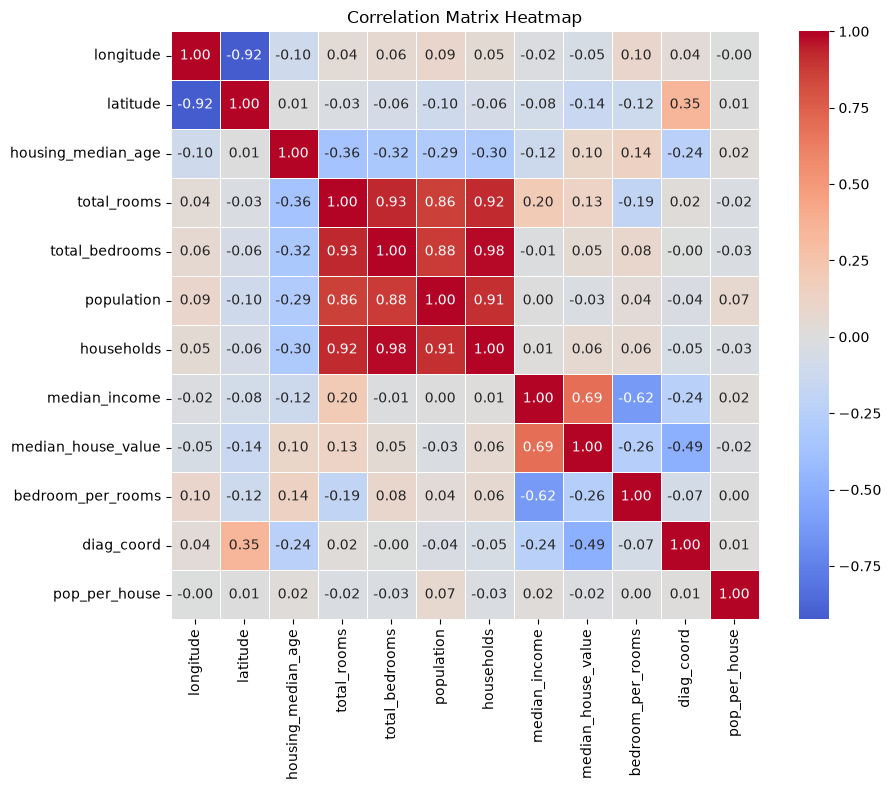

In [134]:
correlation_matrix = train_imputed.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
def plot_geographic_features(
    df: pd.DataFrame,
    feature_1: str,
    feature_2: str,
    point_size: float = 10,
    alpha: float = 0.5,
    cmap: str = 'viridis'
):
    """Plot two numeric features geographically for side-by-side comparison."""
    required_columns = {'longitude', 'latitude', feature_1, feature_2}
    missing_columns = required_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f'Missing columns: {sorted(missing_columns)}')

    non_numeric_features = [
        feature for feature in (feature_1, feature_2)
        if not pd.api.types.is_numeric_dtype(df[feature])
    ]
    if non_numeric_features:
        raise TypeError(
            f'Features must be numeric: {non_numeric_features}'
        )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

    for axis, feature in zip(axes, (feature_1, feature_2)):
        plot_data = df[['longitude', 'latitude', feature]].dropna()
        scatter = axis.scatter(
            plot_data['longitude'],
            plot_data['latitude'],
            c=plot_data[feature],
            s=point_size,
            alpha=alpha,
            cmap=cmap
        )
        axis.set_title(feature.replace('_', ' ').title())
        axis.set_xlabel('Longitude')
        axis.set_ylabel('Latitude')
        axis.grid(alpha=0.2)
        fig.colorbar(scatter, ax=axis, label=feature.replace('_', ' ').title())

    fig.suptitle(f'Geographic Comparison: {feature_1} vs {feature_2}', fontsize=14)
    fig.tight_layout()
    plt.show()
    return fig, axes


plot_geographic_features(
    train_imputed,
    'median_income',
    'median_house_value'
)